In [18]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
train_path = "../data/GTSRB/Final_Training/Images"

print(os.path.exists(train_path))

True


In [20]:
classes = os.listdir(train_path)

print("Number of classes:", len(classes))

Number of classes: 43


In [21]:
image_path = "../data/GTSRB/Final_Training/Images/00000/00000_00000.ppm"

img = cv2.imread(image_path)

print(img.shape)

(30, 29, 3)


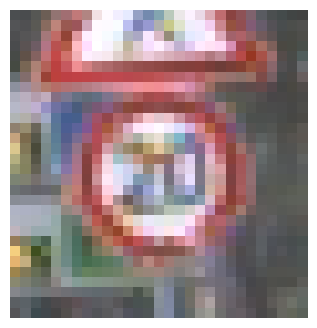

In [22]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.show()

In [23]:
print(os.path.exists(train_path))
print("Number of classes:", len(classes))
print(img.shape)

True
Number of classes: 43
(30, 29, 3)


In [24]:
total_images = 0

for c in classes:
    folder = os.path.join(train_path, c)
    total_images += len(os.listdir(folder))

print("Total images:", total_images)

Total images: 39252


In [25]:
images = []
labels = []

for class_id in classes:

    folder = os.path.join(train_path, class_id)

    for image_name in os.listdir(folder):

        if not image_name.endswith(".ppm"):
            continue

        image_path = os.path.join(folder, image_name)

        img = cv2.imread(image_path)

        img = cv2.resize(img, (32, 32))

        images.append(img)
        labels.append(int(class_id))

In [26]:
X = np.array(images)
y = np.array(labels)

print(X.shape)
print(y.shape)

(39209, 32, 32, 3)
(39209,)


In [27]:
print(X.shape)
print(y.shape)

(39209, 32, 32, 3)
(39209,)


In [28]:
X = X.astype('float32') / 255.0

print(X.min())
print(X.max())

0.0
1.0


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_val.shape)

(31367, 32, 32, 3)
(7842, 32, 32, 3)


In [30]:
import torch
from torch.utils.data import TensorDataset, DataLoader


In [31]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [32]:
type(X_train)
type(y_train)

torch.Tensor

In [33]:
print(X_train.shape)
print(X_val.shape)

torch.Size([31367, 32, 32, 3])
torch.Size([7842, 32, 32, 3])


In [34]:
import torch.nn as nn

class TrafficSignCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)

        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(64 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 43)

    def forward(self, x):

        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [35]:
model = TrafficSignCNN()

In [36]:
print(model)

TrafficSignCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2304, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=43, bias=True)
)


In [37]:
print(X_train.shape)
print(X_val.shape)

torch.Size([31367, 32, 32, 3])
torch.Size([7842, 32, 32, 3])


In [38]:
model = TrafficSignCNN()
print(model)


TrafficSignCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2304, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=43, bias=True)
)


In [39]:
X_train = X_train.permute(0, 3, 1, 2)
X_val = X_val.permute(0, 3, 1, 2)

print(X_train.shape)
print(X_val.shape)

torch.Size([31367, 3, 32, 32])
torch.Size([7842, 3, 32, 32])


In [40]:
model = TrafficSignCNN()
print(model)

TrafficSignCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2304, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=43, bias=True)
)


In [41]:
X_train = X_train.permute(0, 3, 1, 2)
X_val = X_val.permute(0, 3, 1, 2)

print(X_train.shape)
print(X_val.shape)

torch.Size([31367, 32, 3, 32])
torch.Size([7842, 32, 3, 32])


In [42]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

In [43]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [44]:
epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

RuntimeError: Given groups=1, weight of size [32, 3, 3, 3], expected input[64, 32, 3, 32] to have 3 channels, but got 32 channels instead

In [ ]:
print(X_train.shape)
print(X_val.shape)

In [ ]:
X_train = X_train.permute(0, 2, 1, 3)
X_val = X_val.permute(0, 2, 1, 3)

print(X_train.shape)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)

In [ ]:
epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

In [ ]:
torch.save(model.state_dict(), "traffic_sign_model.pth")

In [ ]:
import os
print(os.getcwd())

In [ ]:
torch.save(
    model.state_dict(),
    "../models/traffic_sign_model.pth"
)

In [ ]:
import os
print(os.path.exists("../models/traffic_sign_model.pth"))

In [ ]:
torch.save(
    model.state_dict(),
    "../models/traffic_sign_model.pth"
)

In [ ]:
import os
print(os.path.exists("../models/traffic_sign_model.pth"))

In [ ]:
torch.save(model, "../models/traffic_sign_complete.pth")